## Machine Learning Project: Predicting Life Expectancy

### This project uses machine learning techniques to analyze the relationship between economic and demographic factors and life expectancy.


### We use Linear Regression to predict life expectancy based on:

### - GDP_current_US
### - birth_rate
### - death_rate
### - population_density

## INTRODUCTION

#### Life expectancy is an important indicator of a country's health and development. Many factors such as economic condition, birth rate, death rate, and population density can affect life expectancy.

#### In this project, We use Machine Learning to study how these factors influence life expectancy and to build a prediction model using Linear Regression.

### IMPORT LIBRARIES

#### We import the required libraries for data analysis, visualization,and machine learning.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

### LOAD DATASET

#### The dataset is loaded using pandas. This dataset contains economic and demographic information for different countries.

In [2]:
df=pd.read_csv("C:\DataScience\Data_Set\world_bank_development_indicators.csv")
df.head(5)

,country,date,agricultural_land%,forest_land%,land_area,avg_precipitation,trade_in_services%,control_of_corruption_estimate,control_of_corruption_std,access_to_electricity%,...,multidimensional_poverty_headcount_ratio%,gini_index,birth_rate,death_rate,life_expectancy_at_birth,population,rural_population,voice_and_accountability_estimate,voice_and_accountability_std,intentional_homicides
0,Afghanistan,1960-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,50.340,31.921,32.535,8622466.0,7898093.0,NaN,NaN,NaN
1,Afghanistan,1961-01-01,57.878356,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.443,31.349,33.068,8790140.0,8026804.0,NaN,NaN,NaN
2,Afghanistan,1962-01-01,57.955016,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.570,30.845,33.547,8969047.0,8163985.0,NaN,NaN,NaN
3,Afghanistan,1963-01-01,58.031676,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.703,30.359,34.016,9157465.0,8308019.0,NaN,NaN,NaN
4,Afghanistan,1964-01-01,58.116002,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.831,29.867,34.494,9355514.0,8458694.0,NaN,NaN,NaN


### DATASET INFORMATION

#### We cheak the structure of the dataset , coloumn names, data types and summary statistics.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17272 entries, 0 to 17271
Data columns (total 50 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    17272 non-null  object 
 1   date                                       17272 non-null  object 
 2   agricultural_land%                         14714 non-null  float64
 3   forest_land%                               8176 non-null   float64
 4   land_area                                  14930 non-null  float64
 5   avg_precipitation                          10086 non-null  float64
 6   trade_in_services%                         9195 non-null   float64
 7   control_of_corruption_estimate             4783 non-null   float64
 8   control_of_corruption_std                  4783 non-null   float64
 9   access_to_electricity%                     7348 non-null   float64
 10  renewvable_energy_cons

### DATA CLEANING 

#### Missing values and unnecessary data are removed to make the dataset ready for machine learning.

In [4]:
df.isnull().sum().sort_values(ascending=False)[:20]


doing_business                               17083
time_to_get_operation_license                16901
multidimensional_poverty_headcount_ratio%    16817
human_capital_index                          16671
statistical_performance_indicators           16035
logistic_performance_index                   15865
central_goverment_debt%                      15192
gini_index                                   15164
risk_premium_on_lending                      14902
research_and_development_expenditure%        14383
intentional_homicides                        13063
real_interest_rate                           12856
goverment_effectiveness_std                  12513
goverment_effectiveness_estimate             12513
regulatory_quality_estimate                  12511
regulatory_quality_std                       12511
expense%                                     12503
control_of_corruption_std                    12489
control_of_corruption_estimate               12489
political_stability_std        

In [5]:
df.describe()


,agricultural_land%,forest_land%,land_area,avg_precipitation,trade_in_services%,control_of_corruption_estimate,control_of_corruption_std,access_to_electricity%,renewvable_energy_consumption%,electric_power_consumption,...,multidimensional_poverty_headcount_ratio%,gini_index,birth_rate,death_rate,life_expectancy_at_birth,population,rural_population,voice_and_accountability_estimate,voice_and_accountability_std,intentional_homicides
count,14714.000000,8176.000000,1.493000e+04,10086.000000,9195.000000,4783.000000,4783.000000,7348.000000,8076.000000,7790.000000,...,455.000000,2108.000000,16037.000000,16019.000000,15866.000000,1.666500e+04,1.653900e+04,4850.000000,4850.000000,4209.000000
mean,36.945264,32.408397,5.078664e+06,1214.021416,20.998956,-0.024874,0.203572,80.758176,31.029558,2885.204630,...,27.058386,37.797249,28.203391,10.490354,64.254193,2.159737e+08,1.231026e+08,-0.021062,0.167144,8.035708
std,20.552401,23.355506,1.406167e+07,810.573031,23.260442,1.000047,0.087529,28.745226,29.858553,4103.108667,...,11.262910,8.835216,12.862546,5.358976,11.112156,7.102653e+08,4.087475e+08,0.998757,0.064188,12.026623
min,0.262821,0.000000,2.027000e+00,18.100000,0.621025,-1.936706,0.114062,0.533899,0.000000,5.548906,...,2.370000,20.700000,5.000000,0.795000,11.995000,2.646000e+03,0.000000e+00,-2.313395,0.102437,0.000000
25%,20.454545,12.430556,2.164000e+04,591.000000,8.678157,-0.791694,0.147978,68.435427,5.065460,375.934172,...,18.300000,31.200000,16.438000,6.976522,56.810602,9.940000e+05,4.295845e+05,-0.850328,0.126422,1.348194
50%,37.470745,30.765419,2.419300e+05,1110.000000,13.456865,-0.253887,0.172218,98.290939,20.989980,1331.112025,...,24.800000,35.700000,27.065000,9.200000,66.776719,6.787419e+06,3.148533e+06,0.020768,0.142207,3.428468
75%,50.737179,47.118947,1.444290e+06,1782.000000,24.705827,0.666176,0.227055,100.000000,53.904220,3893.175308,...,33.300000,43.200000,39.752000,12.441818,72.568000,4.641603e+07,2.035198e+07,0.884255,0.196929,9.402278
max,93.440750,98.574551,1.299507e+08,3240.000000,327.166162,2.459118,0.942502,100.000000,98.340000,54799.174708,...,74.200000,65.800000,58.121000,103.534000,85.497561,7.950947e+09,3.435260e+09,1.800992,0.578548,138.773986


### DATA CLEANING 

In [6]:
# Check percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)


doing_business                               98.905743
time_to_get_operation_license                97.852015
multidimensional_poverty_headcount_ratio%    97.365679
human_capital_index                          96.520380
statistical_performance_indicators           92.838119
logistic_performance_index                   91.853868
central_goverment_debt%                      87.957388
gini_index                                   87.795276
risk_premium_on_lending                      86.278370
research_and_development_expenditure%        83.273506
intentional_homicides                        75.631079
real_interest_rate                           74.432608
goverment_effectiveness_std                  72.446735
goverment_effectiveness_estimate             72.446735
regulatory_quality_estimate                  72.435155
regulatory_quality_std                       72.435155
expense%                                     72.388837
control_of_corruption_std                    72.307781
control_of

In [7]:
# Drop columns with more than 50% missing values
threshold = len(df) * 0.5
df_clean = df.dropna(thresh=threshold, axis=1)

print("Original shape:", df.shape)
print("After cleaning shape:", df_clean.shape)


Original shape: (17272, 50)
After cleaning shape: (17272, 15)


In [8]:
# Fill remaining missing values with median
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))


### FEATURE SELECTION 

In [9]:
selected_features = [
    'gdp_per_capita_current_usd',
    'life_expectancy_at_birth_total_years',
    'population_growth_annual_%',
    'individuals_using_the_internet_%',
    'co2_emissions_metric_tons_per_capita',
    'current_health_expenditure_%_of_gdp',
    'agricultural_land_%_of_land_area',
    'urban_population_%_of_total_population',
    'unemployment_total_%_of_labor_force',
    'gini_index'
]


# df_model = df_clean[selected_features + ['multidimensional_poverty_headcount_ratio_%']]
# df_model.head()

In [10]:
df_clean.columns



Index(['country', 'date', 'agricultural_land%', 'land_area',
       'avg_precipitation', 'trade_in_services%', 'population_density',
       'inflation_annual%', 'military_expenditure%', 'GDP_current_US',
       'birth_rate', 'death_rate', 'life_expectancy_at_birth', 'population',
       'rural_population'],
      dtype='object')

In [38]:
[col for col in df_clean.columns if 'poverty' in col.lower()]
[col for col in df_clean.columns if 'gdp' in col.lower()]




['GDP_current_US', 'log_GDP']

In [12]:
[col for col in df_clean.columns if 'life' in col.lower()]

['life_expectancy_at_birth']

In [13]:
[col for col in df_clean.columns if 'internet' in col.lower()]

[]

In [ ]:
[col for col in df_clean.columns if 'unemployment' in col.lower()]



[]

In [15]:
[col for col in df_clean.columns if 'gini' in col.lower()]

[]

In [16]:
df_clean.columns.tolist()


['country',
 'date',
 'agricultural_land%',
 'land_area',
 'avg_precipitation',
 'trade_in_services%',
 'population_density',
 'inflation_annual%',
 'military_expenditure%',
 'GDP_current_US',
 'birth_rate',
 'death_rate',
 'life_expectancy_at_birth',
 'population',
 'rural_population']

In [17]:
df_clean.select_dtypes(include=['int64', 'float64']).columns


Index(['agricultural_land%', 'land_area', 'avg_precipitation',
       'trade_in_services%', 'population_density', 'inflation_annual%',
       'military_expenditure%', 'GDP_current_US', 'birth_rate', 'death_rate',
       'life_expectancy_at_birth', 'population', 'rural_population'],
      dtype='object')

In [18]:
[col for col in df_clean.columns if 'poverty' in col.lower()]


[]

### TRAIN TEST SPLIT

#### The dataset is divided into training and testing sets. 80% data is used for training and 20% for testing.

In [19]:
X = df_clean[['GDP_current_US']]
y = df_clean['life_expectancy_at_birth']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### MODEL TRAINING

#### We use Linear Regression to train the machine learning model.

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### PREDICTION

#### The trained model is used to predict life expectancy for the test dataset.

In [21]:
y_pred = model.predict(X_test)

### EVALUATION

#### We evaluate the model using R² score and RMSE to check prediction accuracy.

In [22]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.02626232669407569
RMSE: 10.567743602323695


### VISUALISATION

#### We compare actual values and predicted values using a scatter plot.

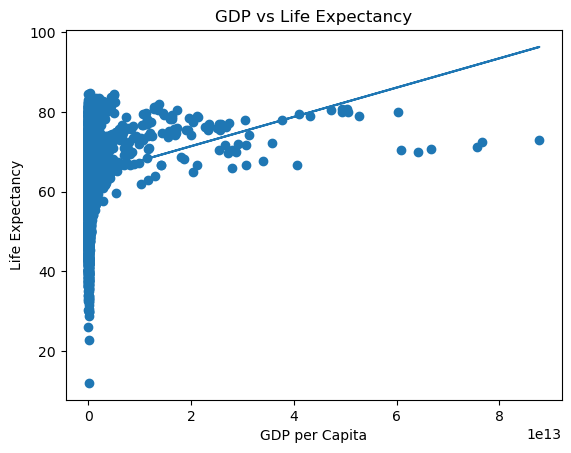

In [23]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("GDP vs Life Expectancy")
plt.show()

In [24]:
df_clean['log_GDP'] = np.log(df_clean['GDP_current_US'])

In [25]:
X = df_clean[['log_GDP']]
y = df_clean['life_expectancy_at_birth']

### TRAIN TEST SPLIT

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### MODEL TRAINING

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### PREDICTION

In [39]:
y_pred = model.predict(X_test)

### EVALUATION

In [ ]:

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("New R2 Score:", r2)
print("New RMSE:", rmse)

New R2 Score: 0.9115898132947158
New RMSE: 3.184288696172916


### VISUALISATION

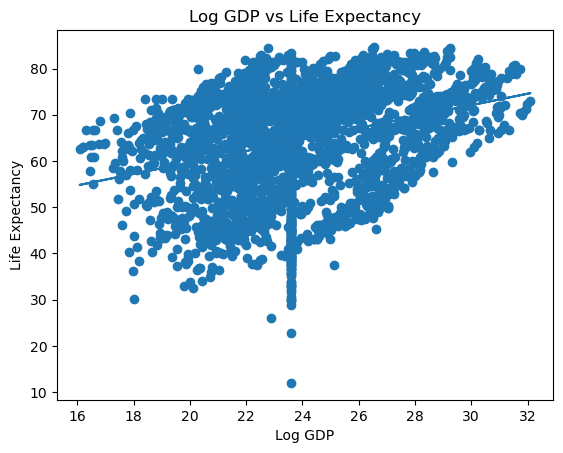

In [29]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Log GDP")
plt.ylabel("Life Expectancy")
plt.title("Log GDP vs Life Expectancy")
plt.show()

In [30]:
X = df_clean[['GDP_current_US','birth_rate','death_rate','population_density']]
y = df_clean['life_expectancy_at_birth']

### TRAIN TEST SPLIT

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### MODEL TRAINING 

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### PREDICTION 

In [41]:
y_pred = model.predict(X_test)

### EVALUATION

In [42]:

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("New R2 Score:", r2)
print("New RMSE:", rmse)

New R2 Score: 0.9115898132947158
New RMSE: 3.184288696172916


### VISUALIZATION 

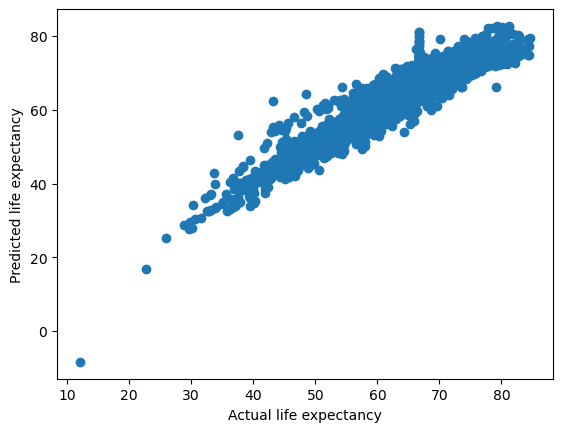

In [34]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual life expectancy")
plt.ylabel("Predicted life expectancy")
plt.show()

### EXPLORATORY DATA ANALYSIS

C:\Users\User\AppData\Local\Temp\ipykernel_16616\2042947595.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_clean.corr(), cmap='coolwarm')


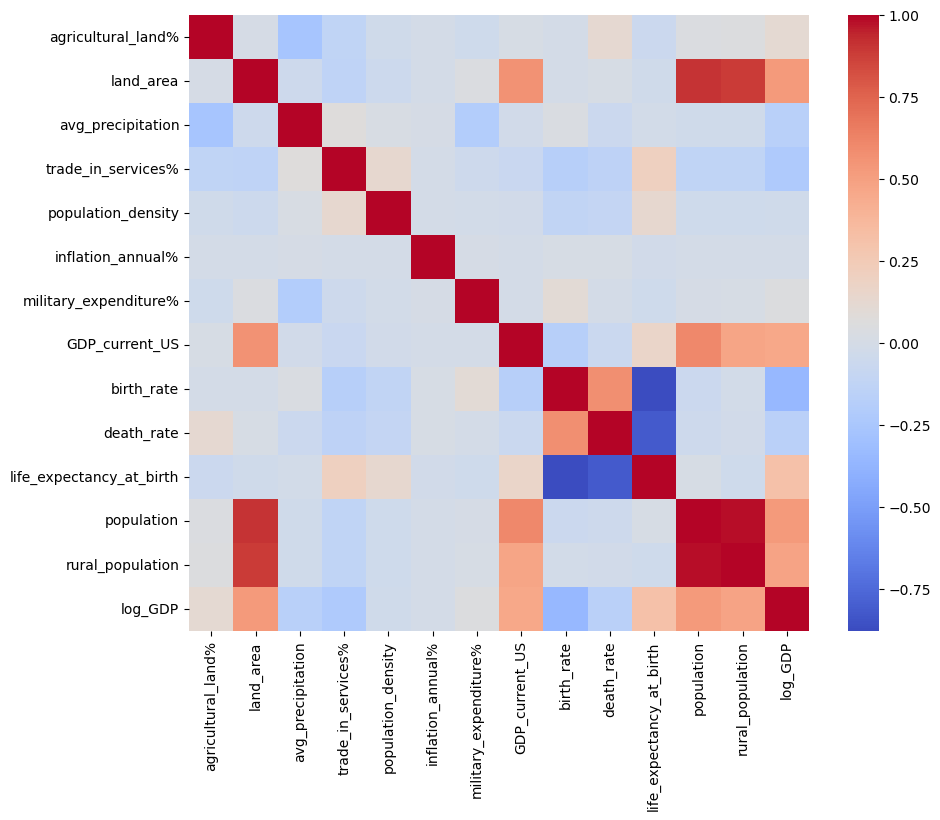

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), cmap='coolwarm')
plt.show()

## CONCLUSION

### In this project, we built a Linear Regression model to predict life expectancy using economic and demographic factors.The results show that GDP, birth rate, death rate, and populationdensity have some influence on life expectancy, but the relationship is not very strong.This suggests that life expectancy depends on many other factors, such as healthcare, education, and living conditions.

### This project demonstrates the basic workflow of a machine learning project including data cleaning, feature selection, model training, evaluation, and visualization.